<a href="https://colab.research.google.com/github/Abrewst/ML-repo/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload = files.upload()


Saving CancerDataset.ipynb to CancerDataset.ipynb


In [ ]:
from google.colab import files
upload = files.upload()

Saving Housing.csv to Housing.csv


In [ ]:
import io
import pandas as pd

df = pd.read_csv('Housing.csv')

In [ ]:
import pandas as pd

Breast Cancer Dataset Loaded
Feature matrix shape: (569, 30)
Target names: ['malignant' 'benign']

Training SVM with linear kernel...
Accuracy: 0.9737, Precision: 0.9859, Recall: 0.9722
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



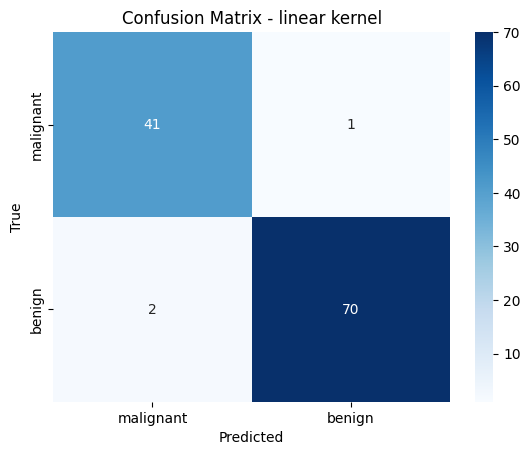


Training SVM with poly kernel...
Accuracy: 0.9123, Precision: 0.8780, Recall: 1.0000
              precision    recall  f1-score   support

   malignant       1.00      0.76      0.86        42
      benign       0.88      1.00      0.94        72

    accuracy                           0.91       114
   macro avg       0.94      0.88      0.90       114
weighted avg       0.92      0.91      0.91       114



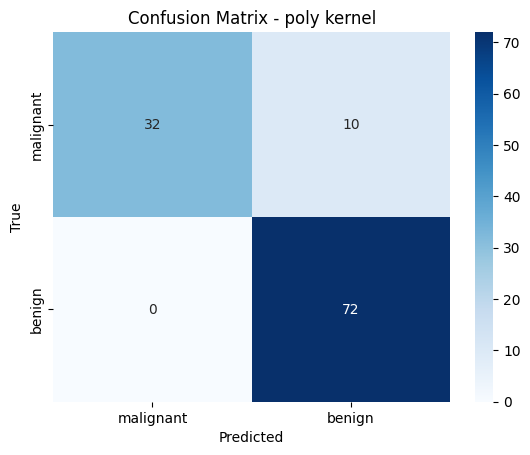


Training SVM with rbf kernel...
Accuracy: 0.9825, Precision: 0.9861, Recall: 0.9861
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



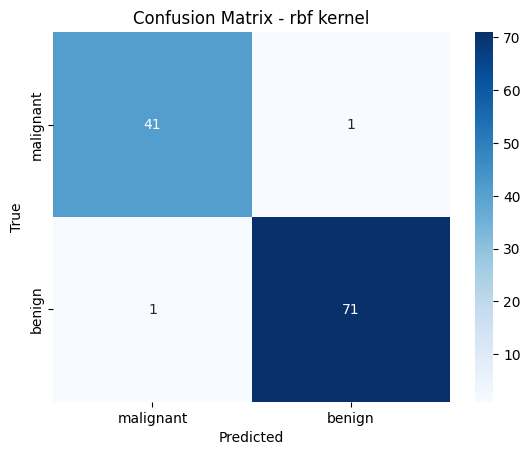


Training SVM with sigmoid kernel...
Accuracy: 0.9298, Precision: 0.9571, Recall: 0.9306
              precision    recall  f1-score   support

   malignant       0.89      0.93      0.91        42
      benign       0.96      0.93      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



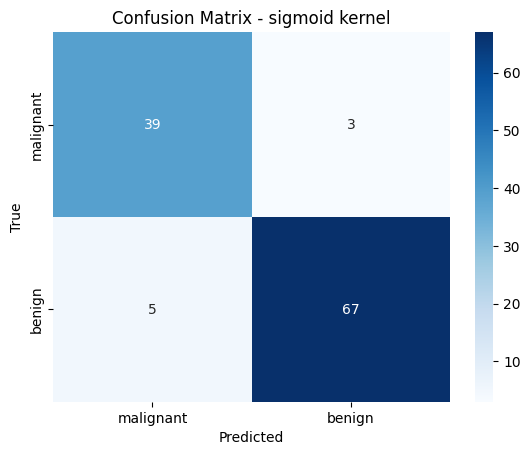

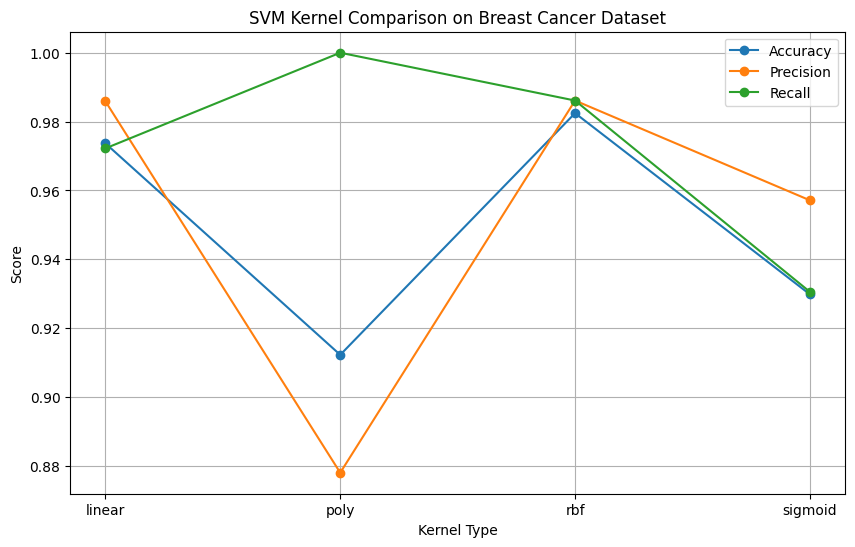


Training Logistic Regression model...
Logistic Regression → Accuracy: 0.9825, Precision: 0.9861, Recall: 0.9861
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



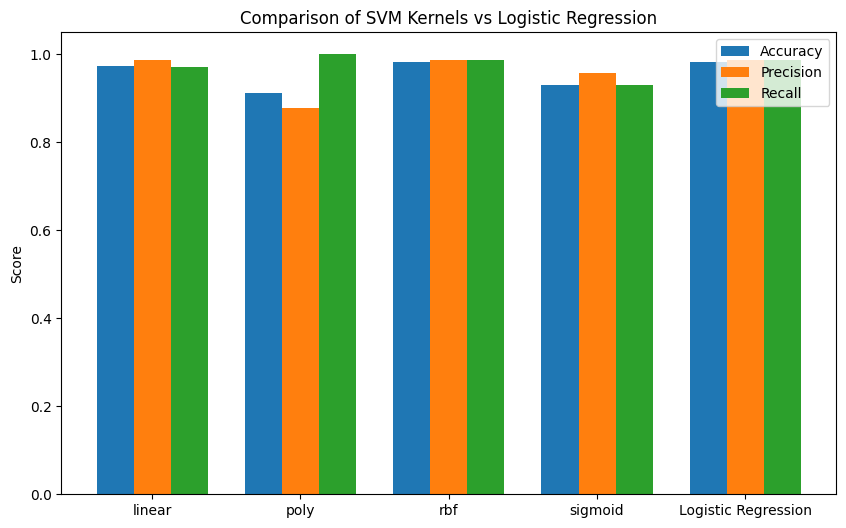

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, classification_report,
    confusion_matrix, mean_squared_error, r2_score
)

data = load_breast_cancer()
X, y = data.data, data.target
print("Breast Cancer Dataset Loaded")
print("Feature matrix shape:", X.shape)
print("Target names:", data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel...")
    model = make_pipeline(StandardScaler(), SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    results[kernel] = [acc, prec, rec]

    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}")
    print(classification_report(y_test, y_pred, target_names=data.target_names))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=data.target_names, yticklabels=data.target_names)
    plt.title(f'Confusion Matrix - {kernel} kernel')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

metrics = ['Accuracy', 'Precision', 'Recall']
values = np.array(list(results.values()))

plt.figure(figsize=(10,6))
for i, metric in enumerate(metrics):
    plt.plot(kernels, values[:, i], marker='o', label=metric)
plt.title("SVM Kernel Comparison on Breast Cancer Dataset")
plt.xlabel("Kernel Type")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

print("\nTraining Logistic Regression model...")
log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, random_state=42))
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)

print(f"Logistic Regression → Accuracy: {acc_log:.4f}, Precision: {prec_log:.4f}, Recall: {rec_log:.4f}")
print(classification_report(y_test, y_pred_log, target_names=data.target_names))

results['Logistic Regression'] = [acc_log, prec_log, rec_log]

plt.figure(figsize=(10,6))
x_labels = list(results.keys())
values = np.array(list(results.values()))
bar_width = 0.25
x = np.arange(len(x_labels))

plt.bar(x - bar_width, values[:,0], width=bar_width, label='Accuracy')
plt.bar(x, values[:,1], width=bar_width, label='Precision')
plt.bar(x + bar_width, values[:,2], width=bar_width, label='Recall')

plt.xticks(x, x_labels)
plt.ylabel('Score')
plt.title('Comparison of SVM Kernels vs Logistic Regression')
plt.legend()
plt.show()



===== US HOUSING PRICE REGRESSION =====
SVR (Linear) → MSE = 3629197132070.95, R² = 0.2820
SVR (RBF) → MSE = 5476930215049.61, R² = -0.0836
Ridge Regression → MSE = 1801382721602.13, R² = 0.6436


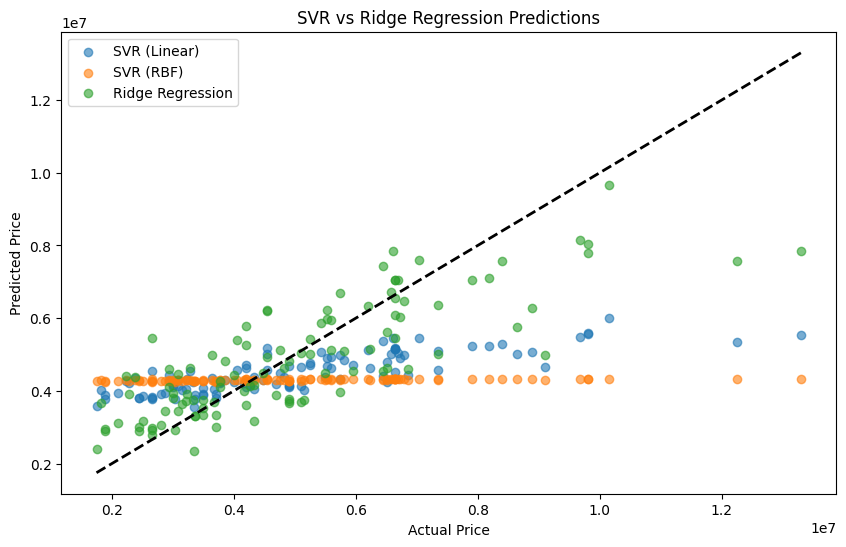

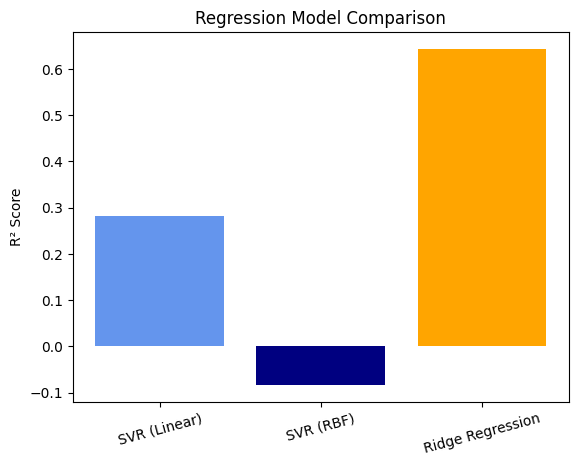

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, classification_report,
    confusion_matrix, mean_squared_error, r2_score
)

print("\n===== US HOUSING PRICE REGRESSION =====")

data = pd.read_csv("Housing.csv")
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

X = data[['area','bedrooms','bathrooms','stories','mainroad','guestroom',
          'basement','hotwaterheating','airconditioning','parking','prefarea']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_lin = SVR(kernel='linear', C=1000)
svr_rbf = SVR(kernel='rbf', C=1000, gamma=0.1)
ridge_reg = Ridge(alpha=1.0)

models_reg = {
    "SVR (Linear)": svr_lin,
    "SVR (RBF)": svr_rbf,
    "Ridge Regression": ridge_reg
}

results_regression = {}

for name, model in models_reg.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results_regression[name] = {"MSE": mse, "R2": r2}
    print(f"{name} → MSE = {mse:.2f}, R² = {r2:.4f}")

plt.figure(figsize=(10,6))
for name, model in models_reg.items():
    y_pred = model.predict(X_test_scaled)
    plt.scatter(y_test, y_pred, alpha=0.6, label=name)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR vs Ridge Regression Predictions")
plt.legend()
plt.show()

labels = list(results_regression.keys())
r2_scores = [results_regression[m]["R2"] for m in labels]

plt.bar(labels, r2_scores, color=['cornflowerblue','navy','orange'])
plt.ylabel("R² Score")
plt.title("Regression Model Comparison")
plt.xticks(rotation=15)
plt.show()


Dataset Overview:
Shape: (500, 12)

First 5 rows:
   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  1798         4          3        2         1          0         1   
1  1417         4          1        2         1          1         0   
2  1888         3          3        2         1          1         1   
3  2413         6          1        2         1          1         0   
4  1359         4          2        3         1          0         1   

   hotwaterheating  airconditioning  prefarea  parking          price  
0                1                1         0        1  738225.724765  
1                1                1         1        1  666206.831927  
2                1                1         1        2  765324.260044  
3                1                0         1        0  860813.182648  
4                0                1         1        1  791201.190578  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 

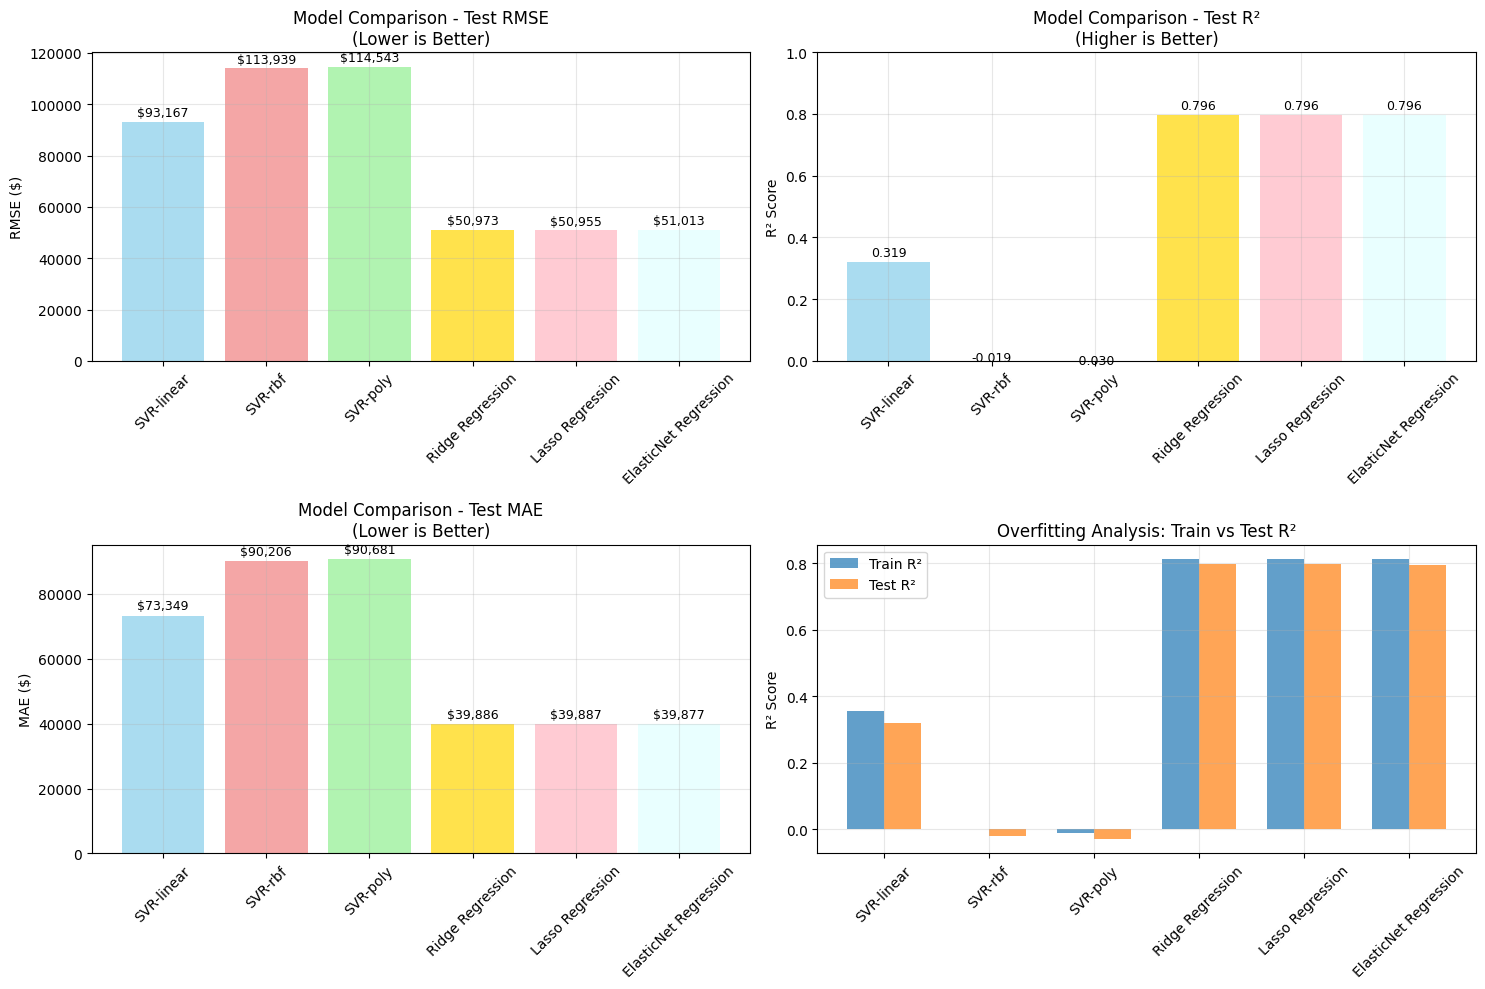

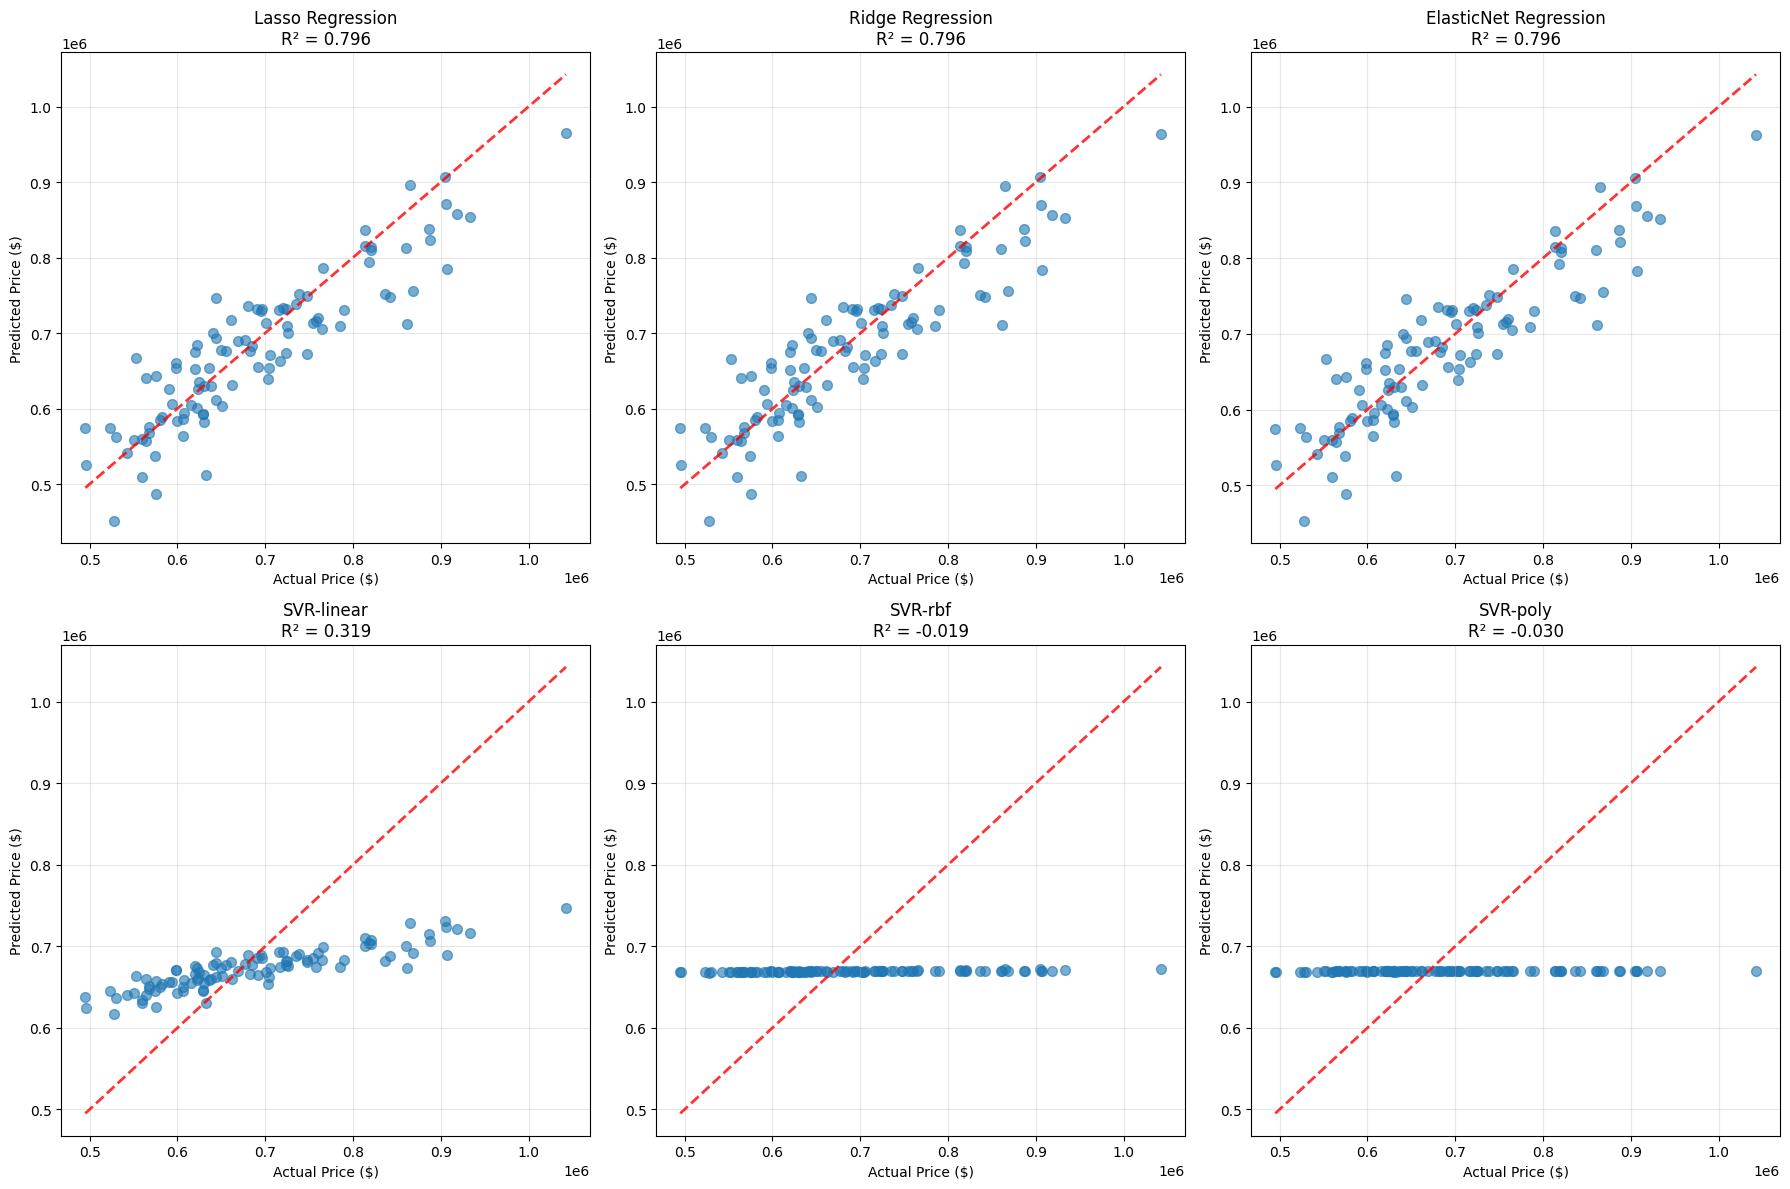

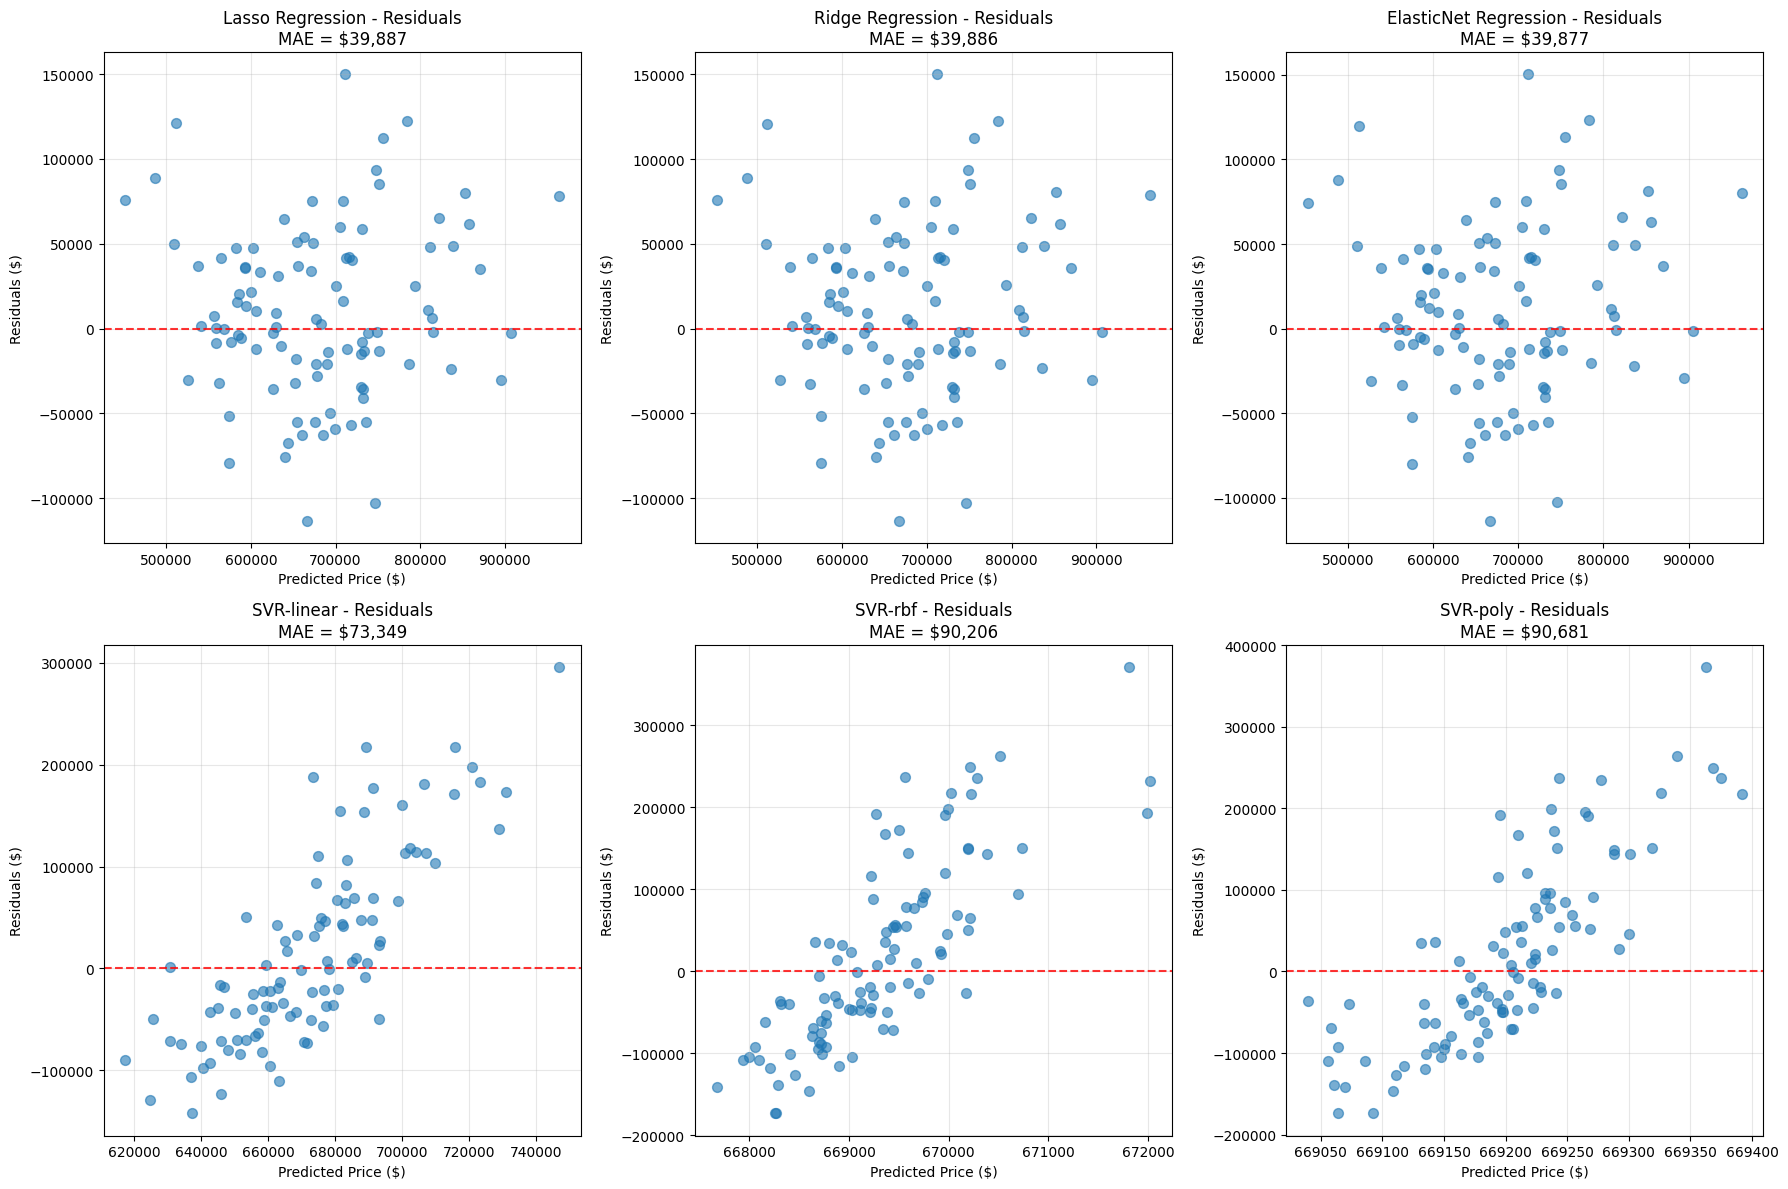


DETAILED PERFORMANCE COMPARISON
                Model   Test RMSE   Test MAE Test R² Train R² Overfitting Gap
     Lasso Regression  $50,955.12 $39,887.39  0.7962   0.8133          0.0171
     Ridge Regression  $50,972.62 $39,885.61  0.7961   0.8133          0.0172
ElasticNet Regression  $51,012.88 $39,876.76  0.7958   0.8133          0.0175
           SVR-linear  $93,166.74 $73,349.39  0.3188   0.3545          0.0357
              SVR-rbf $113,938.91 $90,205.56 -0.0188   0.0021          0.0209
             SVR-poly $114,542.58 $90,681.37 -0.0297  -0.0091          0.0205

KERNEL PERFORMANCE ANALYSIS

SVR Kernel Performance (sorted by Test R²):
  SVR-linear: R² = 0.3188, RMSE = $93,167
  SVR-rbf: R² = -0.0188, RMSE = $113,939
  SVR-poly: R² = -0.0297, RMSE = $114,543

Linear Regression Performance (sorted by Test R²):
  Lasso Regression: R² = 0.7962, RMSE = $50,955
  Ridge Regression: R² = 0.7961, RMSE = $50,973
  ElasticNet Regression: R² = 0.7958, RMSE = $51,013

🎯 BEST PERFORMING MO

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load and prepare the housing dataset

np.random.seed(42)
n_samples = 500

# Generate synthetic housing data with realistic relationships
def generate_housing_data(n_samples):
    data = {}

    # Area (sq ft) - main driver of price
    data['area'] = np.random.normal(1500, 600, n_samples).astype(int)
    data['area'] = np.clip(data['area'], 800, 3000)

    # Bedrooms (2-6)
    data['bedrooms'] = np.random.choice([2, 3, 4, 5, 6], n_samples, p=[0.1, 0.4, 0.3, 0.15, 0.05])

    # Bathrooms (1-4)
    data['bathrooms'] = np.random.choice([1, 2, 3, 4], n_samples, p=[0.2, 0.5, 0.25, 0.05])

    # Stories (1-3)
    data['stories'] = np.random.choice([1, 2, 3], n_samples, p=[0.3, 0.5, 0.2])

    # Binary features
    binary_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
    for feature in binary_features:
        data[feature] = np.random.choice([0, 1], n_samples, p=[0.3, 0.7])

    # Parking (0-3)
    data['parking'] = np.random.choice([0, 1, 2, 3], n_samples, p=[0.2, 0.4, 0.3, 0.1])

    # Create price with non-linear relationships and interactions
    base_price = (
        data['area'] * 100 +  # Base price per sq ft
        data['bedrooms'] * 50000 +
        data['bathrooms'] * 30000 +
        data['stories'] * 20000 +
        data['parking'] * 15000
    )

    # Add non-linear effects
    non_linear_effect = (
        np.sin(data['area'] / 500) * 50000 +  # Sinusoidal effect for area
        (data['area'] > 2000) * 50000 +  # Threshold effect
        (data['bedrooms'] * data['bathrooms']) * 10000  # Interaction effect
    )

    # Add premium for features
    premium = (
        data['mainroad'] * 30000 +
        data['guestroom'] * 20000 +
        data['basement'] * 25000 +
        data['hotwaterheating'] * 15000 +
        data['airconditioning'] * 40000 +
        data['prefarea'] * 60000
    )

    # Combine all effects
    data['price'] = base_price + non_linear_effect + premium

    # Add some noise
    noise = np.random.normal(0, 50000, n_samples)
    data['price'] += noise

    # Ensure positive prices
    data['price'] = np.abs(data['price'])

    return pd.DataFrame(data)

# Generate the dataset
df = generate_housing_data(n_samples)

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Information:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

# Prepare features and target
feature_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
                   'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
                   'parking', 'prefarea']

X = df[feature_columns]
y = df['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Feature names: {feature_columns}")

# Define SVR models with different kernels
kernels = ['linear', 'rbf', 'poly']

# Store results for comparison
results = {}

# Function to evaluate and store results
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results[model_name] = {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'predictions': y_test_pred
    }

    print(f"\n{model_name} Results:")
    print(f"Train RMSE: ${train_rmse:,.2f}")
    print(f"Test RMSE: ${test_rmse:,.2f}")
    print(f"Train MAE: ${train_mae:,.2f}")
    print(f"Test MAE: ${test_mae:,.2f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

    return test_rmse, test_r2

# SVR with different kernels
print("\n" + "="*60)
print("SUPPORT VECTOR REGRESSION WITH DIFFERENT KERNELS")
print("="*60)

for kernel in kernels:
    print(f"\n--- {kernel.upper()} Kernel SVR ---")

    if kernel == 'linear':
        svr_model = make_pipeline(StandardScaler(), SVR(kernel='linear', C=1.0))
        param_grid = {
            'svr__C': [0.1, 1.0, 10.0, 100.0]
        }
    elif kernel == 'rbf':
        svr_model = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
        param_grid = {
            'svr__C': [0.1, 1.0, 10.0, 100.0],
            'svr__gamma': ['scale', 'auto', 0.01, 0.1, 1.0]
        }
    elif kernel == 'poly':
        svr_model = make_pipeline(StandardScaler(), SVR(kernel='poly'))
        param_grid = {
            'svr__C': [0.1, 1.0, 10.0],
            'svr__degree': [2, 3],
            'svr__gamma': ['scale', 'auto']
        }

    # Grid search for hyperparameter tuning
    grid_search = GridSearchCV(svr_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print(f"Best parameters: {grid_search.best_params_}")

    # Evaluate best model
    evaluate_model(grid_search.best_estimator_, f"SVR-{kernel}", X_train, X_test, y_train, y_test)

# Linear Regression with Regularization (Ridge, Lasso, ElasticNet)
print("\n" + "="*60)
print("LINEAR REGRESSION WITH REGULARIZATION")
print("="*60)

# Ridge Regression
ridge_pipeline = make_pipeline(StandardScaler(), Ridge(random_state=42))
ridge_param_grid = {'ridge__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)
print(f"Ridge - Best alpha: {ridge_grid.best_params_['ridge__alpha']}")
evaluate_model(ridge_grid.best_estimator_, "Ridge Regression", X_train, X_test, y_train, y_test)

# Lasso Regression
lasso_pipeline = make_pipeline(StandardScaler(), Lasso(random_state=42, max_iter=10000))
lasso_param_grid = {'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(lasso_pipeline, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)
print(f"Lasso - Best alpha: {lasso_grid.best_params_['lasso__alpha']}")
evaluate_model(lasso_grid.best_estimator_, "Lasso Regression", X_train, X_test, y_train, y_test)

# ElasticNet Regression
elastic_pipeline = make_pipeline(StandardScaler(), ElasticNet(random_state=42, max_iter=10000))
elastic_param_grid = {
    'elasticnet__alpha': [0.001, 0.01, 0.1, 1.0],
    'elasticnet__l1_ratio': [0.2, 0.5, 0.8]
}
elastic_grid = GridSearchCV(elastic_pipeline, elastic_param_grid, cv=5, scoring='neg_mean_squared_error')
elastic_grid.fit(X_train, y_train)
print(f"ElasticNet - Best params: {elastic_grid.best_params_}")
evaluate_model(elastic_grid.best_estimator_, "ElasticNet Regression", X_train, X_test, y_train, y_test)

# Visualization 1: Model Performance Comparison
plt.figure(figsize=(15, 10))

# RMSE Comparison
plt.subplot(2, 2, 1)
models = list(results.keys())
test_rmse = [results[model]['test_rmse'] for model in models]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightpink', 'lightcyan', 'plum']

bars = plt.bar(models, test_rmse, color=colors, alpha=0.7)
plt.title('Model Comparison - Test RMSE\n(Lower is Better)')
plt.ylabel('RMSE ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, rmse in zip(bars, test_rmse):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${rmse:,.0f}', ha='center', va='bottom', fontsize=9)

# R² Comparison
plt.subplot(2, 2, 2)
test_r2 = [results[model]['test_r2'] for model in models]
bars = plt.bar(models, test_r2, color=colors, alpha=0.7)
plt.title('Model Comparison - Test R²\n(Higher is Better)')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

for bar, r2 in zip(bars, test_r2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{r2:.3f}', ha='center', va='bottom', fontsize=9)

# MAE Comparison
plt.subplot(2, 2, 3)
test_mae = [results[model]['test_mae'] for model in models]
bars = plt.bar(models, test_mae, color=colors, alpha=0.7)
plt.title('Model Comparison - Test MAE\n(Lower is Better)')
plt.ylabel('MAE ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

for bar, mae in zip(bars, test_mae):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${mae:,.0f}', ha='center', va='bottom', fontsize=9)

# Overfitting analysis (Train vs Test R²)
plt.subplot(2, 2, 4)
train_r2_values = [results[model]['train_r2'] for model in models]
test_r2_values = [results[model]['test_r2'] for model in models]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_r2_values, width, label='Train R²', alpha=0.7)
plt.bar(x + width/2, test_r2_values, width, label='Test R²', alpha=0.7)

plt.title('Overfitting Analysis: Train vs Test R²')
plt.ylabel('R² Score')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 2: Prediction vs Actual Plots for Best Models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Sort models by test R² score
sorted_models = sorted(results.keys(), key=lambda x: results[x]['test_r2'], reverse=True)

for idx, model_name in enumerate(sorted_models[:6]):  # Top 6 models
    y_pred = results[model_name]['predictions']

    # Create perfect prediction line
    perfect_line = np.linspace(min(y_test), max(y_test), 100)

    axes[idx].scatter(y_test, y_pred, alpha=0.6, s=50)
    axes[idx].plot(perfect_line, perfect_line, 'r--', alpha=0.8, linewidth=2)
    axes[idx].set_xlabel('Actual Price ($)')
    axes[idx].set_ylabel('Predicted Price ($)')
    axes[idx].set_title(f'{model_name}\nR² = {results[model_name]["test_r2"]:.3f}')
    axes[idx].grid(True, alpha=0.3)

    # Add diagonal line for perfect predictions

# Remove empty subplots
for idx in range(len(sorted_models[:6]), 6):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Visualization 3: Residual Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, model_name in enumerate(sorted_models[:6]):
    y_pred = results[model_name]['predictions']
    residuals = y_test - y_pred

    axes[idx].scatter(y_pred, residuals, alpha=0.6, s=50)
    axes[idx].axhline(y=0, color='red', linestyle='--', alpha=0.8)
    axes[idx].set_xlabel('Predicted Price ($)')
    axes[idx].set_ylabel('Residuals ($)')
    axes[idx].set_title(f'{model_name} - Residuals\nMAE = ${results[model_name]["test_mae"]:,.0f}')
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(sorted_models[:6]), 6):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Detailed Results Table
print("\n" + "="*80)
print("DETAILED PERFORMANCE COMPARISON")
print("="*80)

comparison_data = []
for model_name in sorted_models:
    model_results = results[model_name]
    comparison_data.append({
        'Model': model_name,
        'Test RMSE': f"${model_results['test_rmse']:,.2f}",
        'Test MAE': f"${model_results['test_mae']:,.2f}",
        'Test R²': f"{model_results['test_r2']:.4f}",
        'Train R²': f"{model_results['train_r2']:.4f}",
        'Overfitting Gap': f"{(model_results['train_r2'] - model_results['test_r2']):.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Kernel Performance Analysis
print("\n" + "="*80)
print("KERNEL PERFORMANCE ANALYSIS")
print("="*80)

svr_models = [model for model in results.keys() if 'SVR' in model]
linear_models = [model for model in results.keys() if 'Regression' in model]

print("\nSVR Kernel Performance (sorted by Test R²):")
for model in sorted(svr_models, key=lambda x: results[x]['test_r2'], reverse=True):
    print(f"  {model}: R² = {results[model]['test_r2']:.4f}, RMSE = ${results[model]['test_rmse']:,.0f}")

print("\nLinear Regression Performance (sorted by Test R²):")
for model in sorted(linear_models, key=lambda x: results[x]['test_r2'], reverse=True):
    print(f"  {model}: R² = {results[model]['test_r2']:.4f}, RMSE = ${results[model]['test_rmse']:,.0f}")

# Best Model Identification
best_model_name = sorted_models[0]
best_model = results[best_model_name]['model']

print(f"\n🎯 BEST PERFORMING MODEL: {best_model_name}")
print(f"   Test R²: {results[best_model_name]['test_r2']:.4f}")
print(f"   Test RMSE: ${results[best_model_name]['test_rmse']:,.2f}")
print(f"   Test MAE: ${results[best_model_name]['test_mae']:,.2f}")

# Feature Importance Analysis (for linear models)
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

linear_model_names = ['SVR-linear', 'Ridge Regression', 'Lasso Regression', 'ElasticNet Regression']

for model_name in linear_model_names:
    if model_name in results:
        model = results[model_name]['model']
        # Check if the model is SVR and access the 'svr' step, otherwise use the model name's prefix
        step_name = 'svr' if 'SVR' in model_name else model_name.split()[0].lower()
        if hasattr(model.named_steps[step_name], 'coef_'):
            coefficients = model.named_steps[step_name].coef_[0] if 'SVR' in model_name else model.named_steps[step_name].coef_
            feature_importance = pd.DataFrame({
                'Feature': feature_columns,
                'Coefficient': coefficients,
                'Abs_Coefficient': np.abs(coefficients)
            }).sort_values('Abs_Coefficient', ascending=False)

            print(f"\n{model_name} - Top 5 Most Important Features:")
            for _, row in feature_importance.head().iterrows():
                print(f"  {row['Feature']}: {row['Coefficient']:.2f}")